<a href="https://colab.research.google.com/github/franciscosrcoelho-coder/Google-Colab/blob/main/Welcome_To_Colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [46]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow.keras.layers import Dense, Input
from tensorflow.keras.models import Model

np.random.seed(123)
tf.random.set_seed(123)

In [47]:
!pip install -U scikit-learn

In [48]:
from sklearn.metrics import mean_absolute_percentage_error

In [49]:
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt

import warnings
warnings.filterwarnings('ignore')

from sklearn.metrics import mean_absolute_percentage_error, \
  mean_absolute_error, r2_score, mean_squared_error

In [50]:
url = 'https://raw.githubusercontent.com/franciscosrcoelho-coder/Google-Colab/refs/heads/main/Data%20Science%20Applications%20Project%20Data.csv'
df = pd.read_csv(url)

In [51]:
# add the date attribute starting from Jan 2000, with a monthly frequency
df['year_month'] = pd.date_range(start='1/2016', end='4/2026', freq='M',
                                    inclusive='both')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 123 entries, 0 to 122
Data columns (total 3 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   Month        123 non-null    object        
 1   Consumption  123 non-null    int64         
 2   year_month   123 non-null    datetime64[ns]
dtypes: datetime64[ns](1), int64(1), object(1)
memory usage: 3.0+ KB


In [52]:
df=df.drop('Month',axis=1)

In [53]:
df.set_index('year_month', inplace=True)

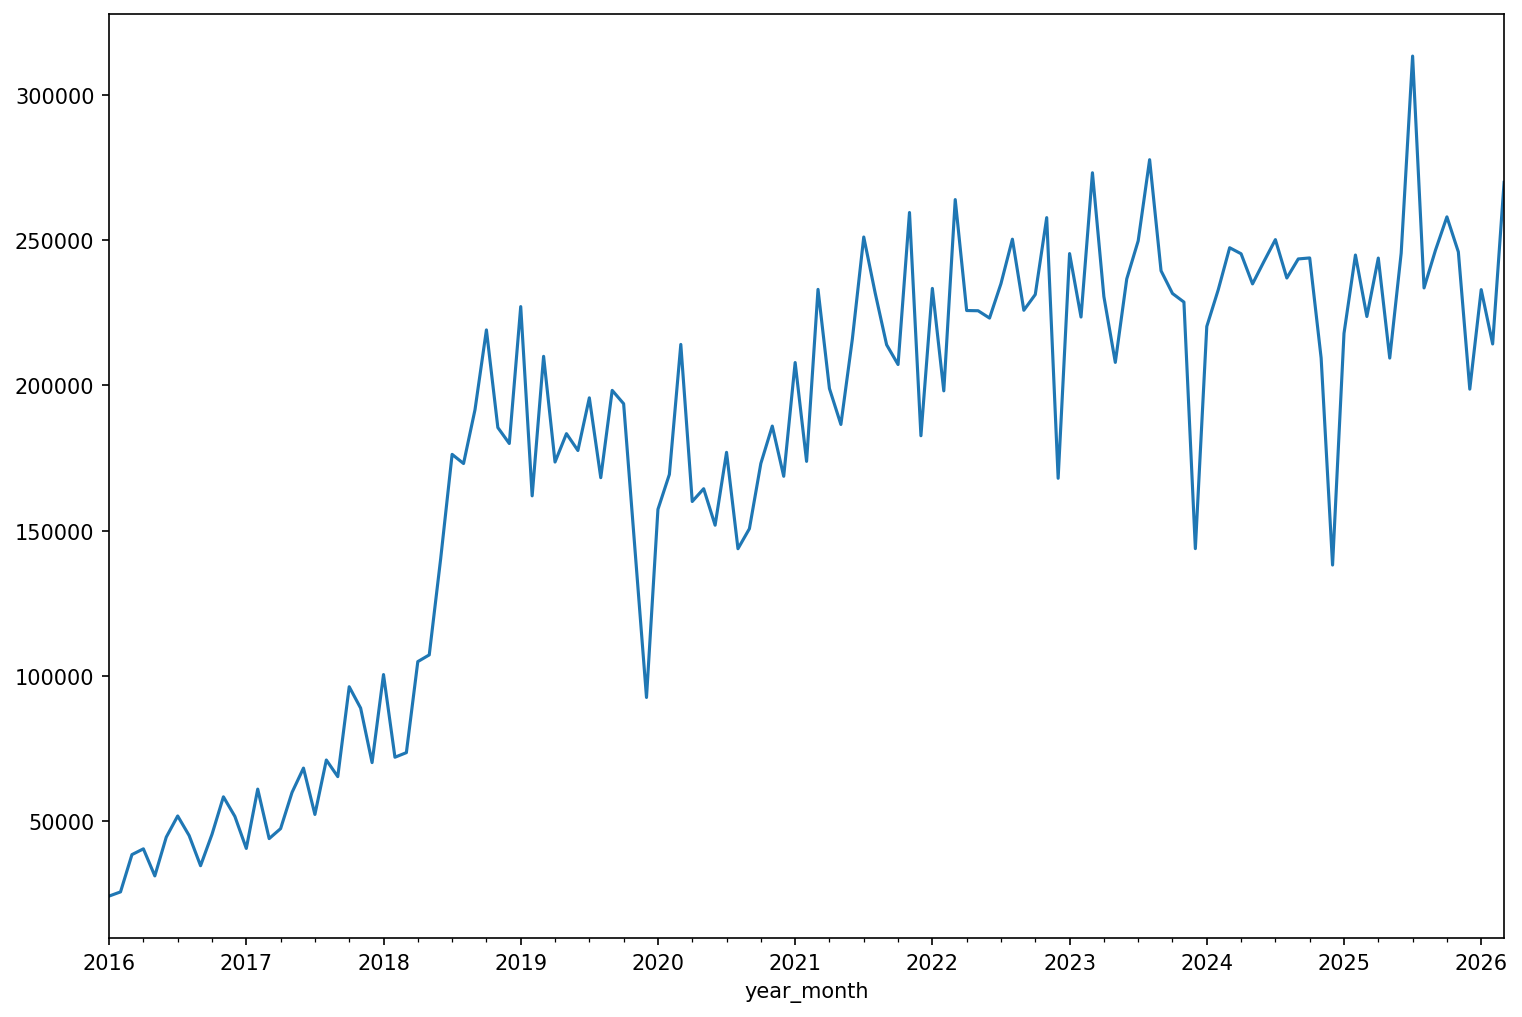

In [54]:
plt.figure(figsize=(12,8),dpi=150)
df['Consumption'].plot();

In [55]:
df.head()

,Consumption
year_month,
2016-01-31,24273
2016-02-29,25715
2016-03-31,38543
2016-04-30,40524
2016-05-31,31222


In [56]:
Ntest = 12
train = df.iloc[:-Ntest]
test = df.iloc[-Ntest:]

In [57]:
# boolean series to index df rows
train_idx = df.index <= train.index[-1]
test_idx = df.index > train.index[-1]

In [58]:
df['DiffConsumption'] = df['Consumption'].diff()

In [59]:
# Make supervised dataset
series = df['DiffConsumption'].dropna().to_numpy()

T = 10
X = []
Y = []
for t in range(len(series) - T):
  x = series[t:t+T]
  X.append(x)
  y = series[t+T]
  Y.append(y)

X = np.array(X).reshape(-1, T)
Y = np.array(Y)
N = len(X)
print("X.shape", X.shape, "Y.shape", Y.shape)

X.shape (112, 10) Y.shape (112,)


In [60]:
Xtrain, Ytrain = X[:-Ntest], Y[:-Ntest]
Xtest, Ytest = X[-Ntest:], Y[-Ntest:]

# **ANN**

In [61]:
# Basic ANN
i = Input(shape=(T,))
x = Dense(32, activation='relu')(i)
x = Dense(1)(x)
model = Model(i, x)

In [62]:
model.compile(
  loss='mse',
  optimizer='adam',
)

In [63]:
r = model.fit(
  Xtrain,
  Ytrain,
  epochs=150,
  validation_data=(Xtest, Ytest)
)

Epoch 1/150
4/4 ━━━━━━━━━━━━━━━━━━━━ 2s 106ms/step - loss: 1911871872.0000 - val_loss: 2175166208.0000
Epoch 2/150
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step - loss: 1802325248.0000 - val_loss: 2101170688.0000
Epoch 3/150
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step - loss: 1718088064.0000 - val_loss: 2034667904.0000
Epoch 4/150
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step - loss: 1642540672.0000 - val_loss: 1974541440.0000
Epoch 5/150
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step - loss: 1573810944.0000 - val_loss: 1920378240.0000
Epoch 6/150
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step - loss: 1511123328.0000 - val_loss: 1871791488.0000
Epoch 7/150
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step - loss: 1454203520.0000 - val_loss: 1828535296.0000
Epoch 8/150
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - loss: 1402456320.0000 - val_loss: 1790303360.0000
Epoch 9/150
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step - loss: 1355762560.0000 - val_loss: 1756486272.0000
Epoch 10/150
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - loss: 1313718016.0000 - val_

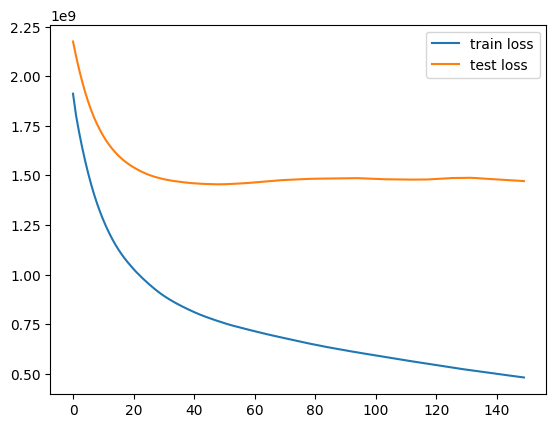

In [64]:
plt.plot(r.history['loss'], label='train loss')
plt.plot(r.history['val_loss'], label='test loss')
plt.legend();

In [65]:
train_idx[:T+1] = False # first T+1 values are not predictable

In [66]:
Ptrain = model.predict(Xtrain).flatten()
Ptest = model.predict(Xtest).flatten()

1/4 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step


In [67]:
# Store diff predictions
df.loc[train_idx, 'Diff ANN Train Prediction'] = Ptrain
df.loc[test_idx, 'Diff ANN Test Prediction'] = Ptest

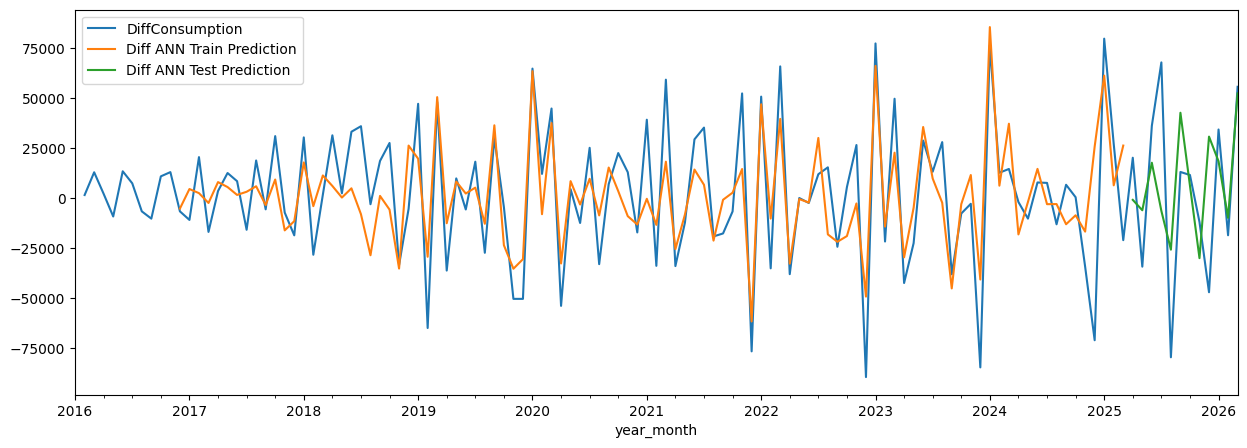

In [68]:
cols = ['DiffConsumption',
        'Diff ANN Train Prediction',
        'Diff ANN Test Prediction']
df[cols].plot(figsize=(15, 5));

In [69]:
# Needed to compute un-differenced predictions
df['ShiftConsumption'] = df['Consumption'].shift(1)
prev = df['ShiftConsumption']

In [70]:
# Last-known train value
last_train = train.iloc[-1]['Consumption']

In [71]:
# 1-step forecast
df.loc[train_idx, '1step_train'] = prev[train_idx] + Ptrain
df.loc[test_idx, '1step_test'] = prev[test_idx] + Ptest

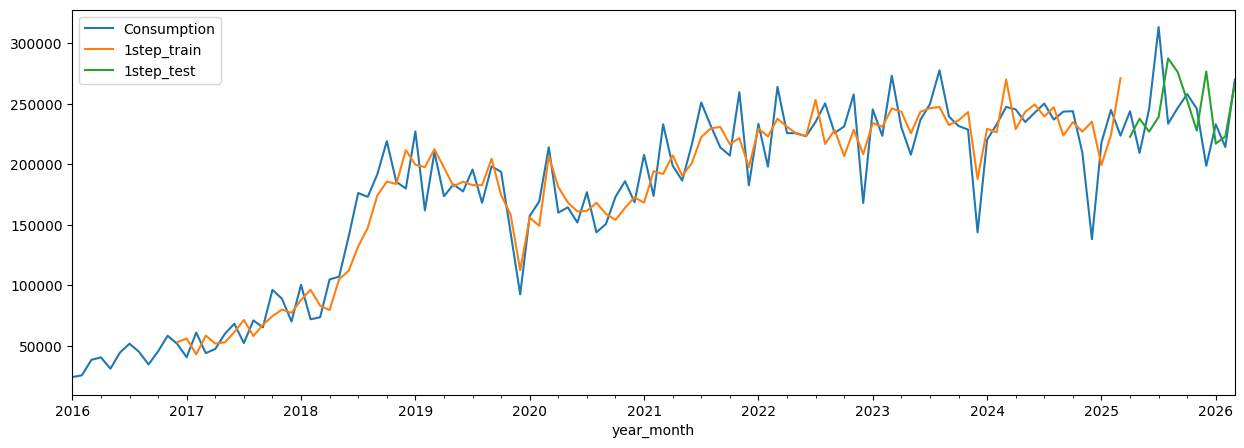

In [72]:
# plot 1-step forecast
df[['Consumption', '1step_train', '1step_test']].plot(figsize=(15, 5));

In [73]:
# multi-step forecast
multistep_predictions = []

# first test input
last_x = Xtest[0]

while len(multistep_predictions) < Ntest:
  p = model.predict(last_x.reshape(1, -1))[0]

  # update the predictions list
  multistep_predictions.append(p)

  # make the new input
  last_x = np.roll(last_x, -1)
  last_x[-1] = p

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step


In [74]:
# save multi-step forecast to dataframe
df.loc[test_idx, 'multistep'] = last_train + np.cumsum(multistep_predictions)

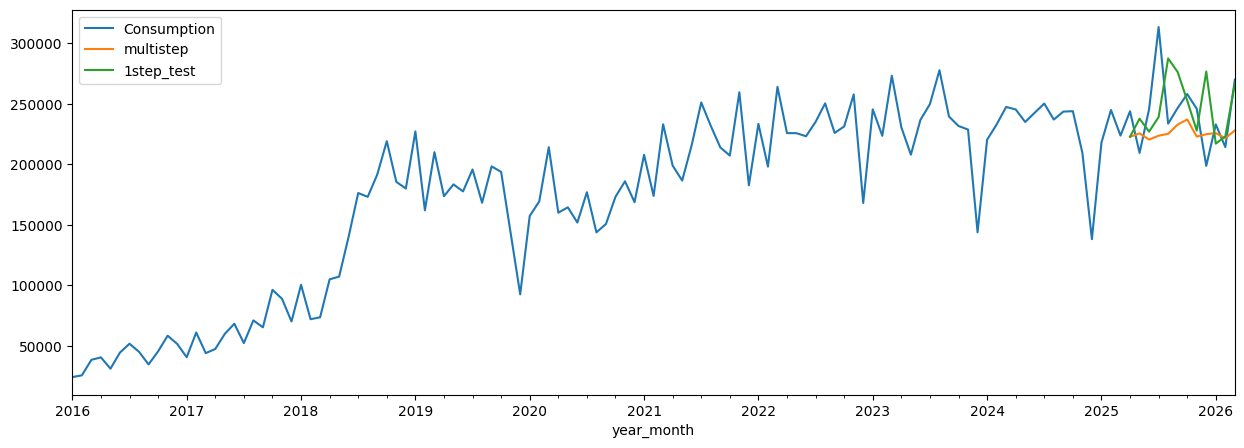

In [75]:
# plot 1-step and multi-step forecast
df[['Consumption', 'multistep', '1step_test']].plot(figsize=(15, 5));

In [76]:
# make multi-output supervised dataset
Tx = T
Ty = Ntest
X = []
Y = []
for t in range(len(series) - Tx - Ty + 1):
  x = series[t:t+Tx]
  X.append(x)
  y = series[t+Tx:t+Tx+Ty]
  Y.append(y)

X = np.array(X).reshape(-1, Tx)
Y = np.array(Y).reshape(-1, Ty)
N = len(X)
print("X.shape", X.shape, "Y.shape", Y.shape)

X.shape (101, 10) Y.shape (101, 12)


In [77]:
Xtrain_m, Ytrain_m = X[:-1], Y[:-1]
Xtest_m, Ytest_m = X[-1:], Y[-1:]

In [78]:
# Basic ANN
i = Input(shape=(Tx,))
x = Dense(32, activation='relu')(i)
x = Dense(Ty)(x)
model = Model(i, x)

In [79]:
model.compile(
  loss='mse',
  optimizer='adam',
)

In [80]:
r = model.fit(
  Xtrain_m,
  Ytrain_m,
  epochs=150,
  validation_data=(Xtest_m, Ytest_m)
)

Epoch 1/150
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 64ms/step - loss: 1654339456.0000 - val_loss: 2152196096.0000
Epoch 2/150
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 1602318464.0000 - val_loss: 2123894912.0000
Epoch 3/150
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 1557625216.0000 - val_loss: 2097134592.0000
Epoch 4/150
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 1516079232.0000 - val_loss: 2071387520.0000
Epoch 5/150
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 1477303168.0000 - val_loss: 2046316928.0000
Epoch 6/150
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 1441049472.0000 - val_loss: 2021676416.0000
Epoch 7/150
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 1407063680.0000 - val_loss: 1997473792.0000
Epoch 8/150
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 1375094400.0000 - val_loss: 1973724544.0000
Epoch 9/150
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 1345238272.0000 - val_loss: 1950471808.0000
Epoch 10/150
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 1317456128.0000 - val_l

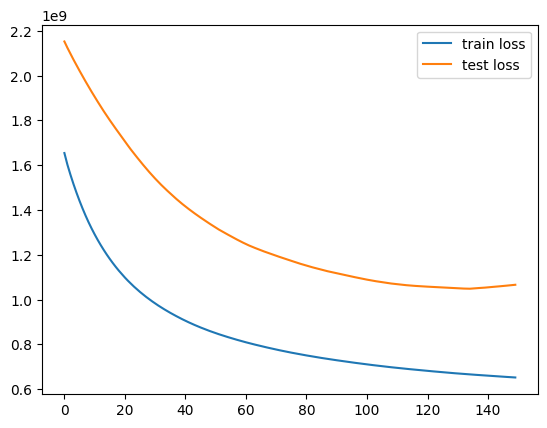

In [81]:
plt.plot(r.history['loss'], label='train loss')
plt.plot(r.history['val_loss'], label='test loss')
plt.legend();

In [82]:
Ptrain = model.predict(Xtrain_m)
Ptest = model.predict(Xtest_m)

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step


In [83]:
Ptrain.shape, Ptest.shape

((100, 12), (1, 12))

In [84]:
Ptrain = Ptrain[:,0]
Ptest = Ptest[0]

In [85]:
# save multi-output forecast to dataframe
df.loc[test_idx, 'multioutput'] = last_train + \
  np.cumsum(Ptest)

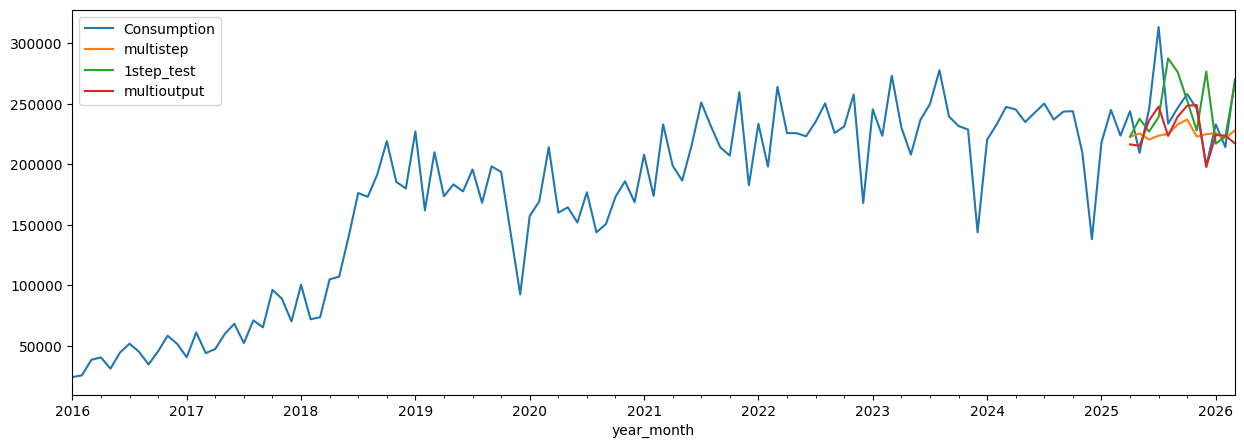

In [86]:
# plot all forecasts
cols = ['Consumption', 'multistep', '1step_test', 'multioutput']
df[cols].plot(figsize=(15, 5));

In [87]:
import math

In [88]:
test_log_pass = df.iloc[-Ntest:]['Consumption']

mae1 = mean_absolute_error(
    test_log_pass, df.loc[test_idx, 'multistep'])
print("multi-step MAE:", mae1)
mape1 = mean_absolute_percentage_error(
    test_log_pass, df.loc[test_idx, 'multistep'])
print("multi-step MAPE:", mape1)
rmse1 = math.sqrt(mean_squared_error(test_log_pass, df.loc[test_idx, 'multistep']))
print("multi-step RMSE:", rmse1)
mae2 = mean_absolute_error(
    test_log_pass, df.loc[test_idx, 'multioutput'])
print("multi-output MAE:", mae2)
mape2 = mean_absolute_percentage_error(
    test_log_pass, df.loc[test_idx, 'multioutput'])
print("multi-output MAPE:", mape2)
rmse2 = math.sqrt(mean_squared_error(test_log_pass, df.loc[test_idx, 'multioutput']))
print("multi-output MAPE:", rmse2)

multi-step MAE: 25058.48612467448
multi-step MAPE: 0.09755011831461856
multi-step RMSE: 33108.85826390223
multi-output MAE: 17489.056752522785
multi-output MAPE: 0.06592600147905499
multi-output MAPE: 26416.967887285435


# **CNN**

In [89]:
df.head()

,Consumption,DiffConsumption,Diff ANN Train Prediction,Diff ANN Test Prediction,ShiftConsumption,1step_train,1step_test,multistep,multioutput
year_month,,,,,,,,,
2016-01-31,24273,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2016-02-29,25715,1442.0,NaN,NaN,24273.0,NaN,NaN,NaN,NaN
2016-03-31,38543,12828.0,NaN,NaN,25715.0,NaN,NaN,NaN,NaN
2016-04-30,40524,1981.0,NaN,NaN,38543.0,NaN,NaN,NaN,NaN
2016-05-31,31222,-9302.0,NaN,NaN,40524.0,NaN,NaN,NaN,NaN


In [90]:
df.columns

Index(['Consumption', 'DiffConsumption', 'Diff ANN Train Prediction',
       'Diff ANN Test Prediction', 'ShiftConsumption', '1step_train',
       '1step_test', 'multistep', 'multioutput'],
      dtype='object')

In [91]:
df=df.drop(['Diff ANN Train Prediction',
       'Diff ANN Test Prediction', 'ShiftConsumption', '1step_train',
       '1step_test', 'multistep', 'multioutput'],axis=1)

In [92]:
import tensorflow as tf
from tensorflow.keras.layers import Dense, Input, GlobalMaxPooling1D
from tensorflow.keras.layers import Conv1D, MaxPooling1D
from tensorflow.keras.models import Model

In [93]:
# CNN
i = Input(shape=(T, 1))
x = Conv1D(16, 3, activation='relu')(i)
x = MaxPooling1D(2)(x)
x = Conv1D(32, 3, activation='relu')(x)
x = GlobalMaxPooling1D()(x)
x = Dense(1)(x)
model = Model(i, x)

In [94]:
model.summary()

Model: "functional_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_4 (InputLayer)      │ (None, 10, 1)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d (Conv1D)                 │ (None, 8, 16)          │            64 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 4, 16)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 2, 32)          │         1,568 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_max_pooling1d            │ (None, 32)             │             0 │
│ (GlobalMaxPooling1D)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,665 (6.50 KB)

 Trainable params: 1,665 (6.50 KB)

 Non-trainable params: 0 (0.00 B)

In [95]:
model.compile(
  loss='mse',
  optimizer='adam',
)

In [96]:
# CNN
i = Input(shape=(T, 1), dtype=tf.float32)
x = Conv1D(16, 3, activation='relu')(i)
x = MaxPooling1D(2)(x)
x = Conv1D(32, 3, activation='relu')(x)
x = GlobalMaxPooling1D()(x)
x = Dense(1)(x)
model = Model(i, x)

model.compile(
  loss='mse',
  optimizer='adam',
)

Xtrain_cnn = Xtrain.reshape(-1, T, 1).astype(np.float32)
Ytrain_cnn = Ytrain.astype(np.float32)
Xtest_cnn = Xtest.reshape(-1, T, 1).astype(np.float32)
Ytest_cnn = Ytest.astype(np.float32)

r = model.fit(
  Xtrain_cnn,
  Ytrain_cnn,
  epochs=100,
  validation_data=(Xtest_cnn, Ytest_cnn)
)

Epoch 1/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 74ms/step - loss: 1488653056.0000 - val_loss: 2431005440.0000
Epoch 2/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - loss: 1305831936.0000 - val_loss: 2272678656.0000
Epoch 3/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 1216208512.0000 - val_loss: 2218229504.0000
Epoch 4/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 1184707328.0000 - val_loss: 2218658048.0000
Epoch 5/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 1177123584.0000 - val_loss: 2220769536.0000
Epoch 6/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 1170485888.0000 - val_loss: 2213946112.0000
Epoch 7/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - loss: 1159054976.0000 - val_loss: 2202388224.0000
Epoch 8/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 1145471744.0000 - val_loss: 2192343040.0000
Epoch 9/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 1133561728.0000 - val_loss: 2189048320.0000
Epoch 10/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 1123550848.0000 - val_l

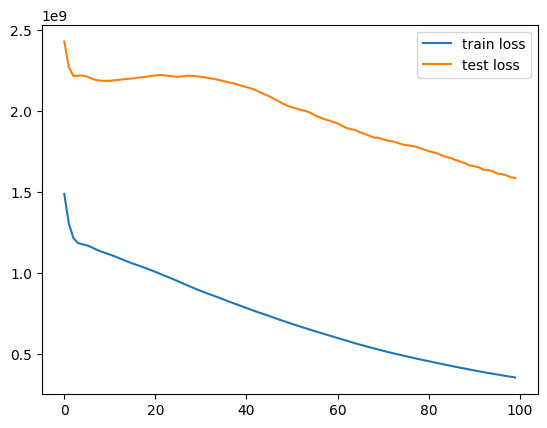

In [97]:
plt.plot(r.history['loss'], label='train loss')
plt.plot(r.history['val_loss'], label='test loss')
plt.legend();

In [98]:
train_idx[:T+1] = False # first T+1 values are not predictable

In [99]:
Ptrain = model.predict(Xtrain_cnn).flatten()
Ptest = model.predict(Xtest_cnn).flatten()

1/4 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step


In [100]:
# Store diff predictions
df.loc[train_idx, 'Diff Train Prediction'] = Ptrain
df.loc[test_idx, 'Diff Test Prediction'] = Ptest

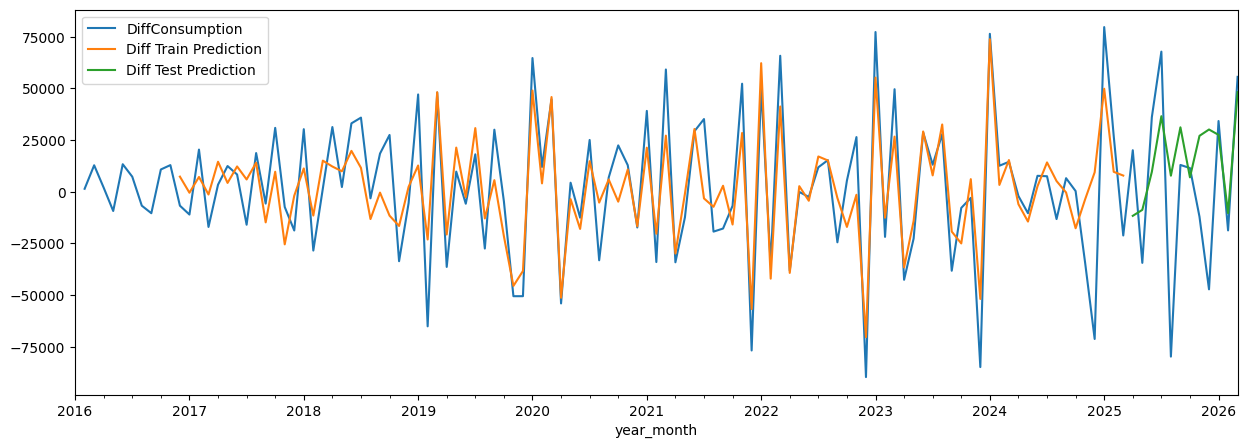

In [101]:
cols = ['DiffConsumption',
        'Diff Train Prediction',
        'Diff Test Prediction']
df[cols].plot(figsize=(15, 5));

In [102]:
# Needed to compute un-differenced predictions
df['ShiftConsumption'] = df['Consumption'].shift(1)
prev = df['ShiftConsumption']

In [103]:
# Last-known train value
last_train = train.iloc[-1]['Consumption']

In [104]:
# 1-step forecast
df.loc[train_idx, '1step_train'] = prev[train_idx] + Ptrain
df.loc[test_idx, '1step_test'] = prev[test_idx] + Ptest

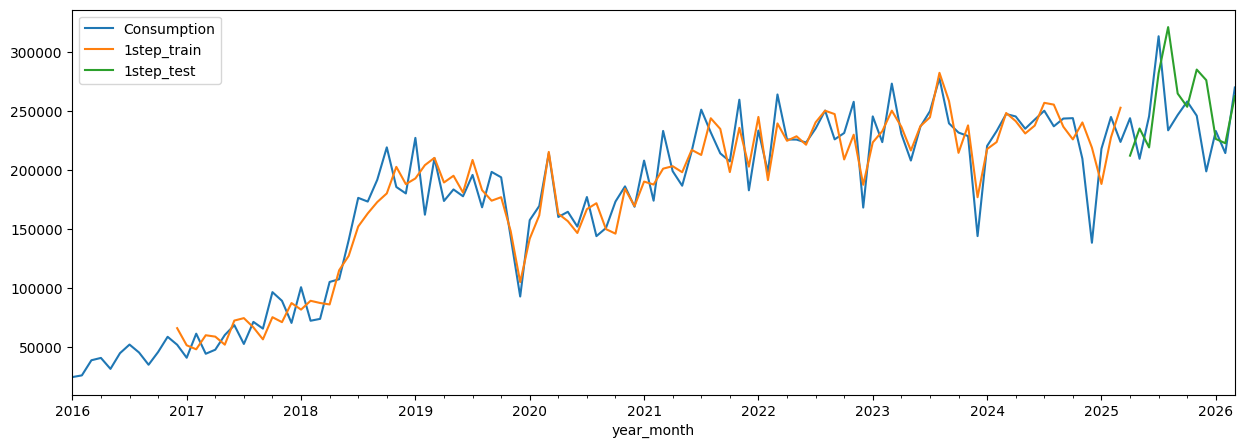

In [105]:
# plot 1-step forecast
df[['Consumption', '1step_train', '1step_test']].plot(figsize=(15, 5));

In [106]:
# multi-step forecast
multistep_predictions = []

# first test input
last_x = Xtest[0]

while len(multistep_predictions) < Ntest:
  p = model.predict(last_x.reshape(1, -1, 1))[0]

  # update the predictions list
  multistep_predictions.append(p)

  # make the new input
  last_x = np.roll(last_x, -1)
  last_x[-1] = p

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step


In [107]:
# save multi-step forecast to dataframe
df.loc[test_idx, 'multistep'] = last_train + np.cumsum(multistep_predictions)

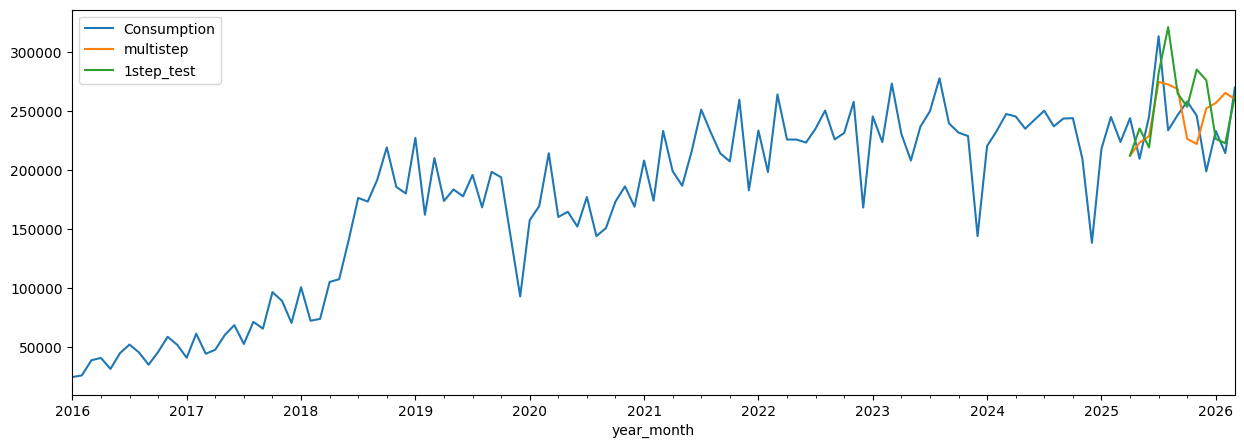

In [108]:
# plot 1-step and multi-step forecast
df[['Consumption', 'multistep', '1step_test']].plot(figsize=(15, 5));

In [109]:
# make multi-output supervised dataset
Tx = T
Ty = Ntest
X = []
Y = []
for t in range(len(series) - Tx - Ty + 1):
  x = series[t:t+Tx]
  X.append(x)
  y = series[t+Tx:t+Tx+Ty]
  Y.append(y)

X = np.array(X).reshape(-1, Tx, 1)
Y = np.array(Y).reshape(-1, Ty)
N = len(X)
print("X.shape", X.shape, "Y.shape", Y.shape)

X.shape (101, 10, 1) Y.shape (101, 12)


In [110]:
Xtrain_m, Ytrain_m = X[:-1], Y[:-1]
Xtest_m, Ytest_m = X[-1:], Y[-1:]

In [111]:
# CNN
i = Input(shape=(Tx, 1))
x = Conv1D(16, 3, activation='relu')(i)
x = MaxPooling1D(2)(x)
x = Conv1D(32, 3, activation='relu')(x)
x = GlobalMaxPooling1D()(x)
x = Dense(Ty)(x)
model = Model(i, x)

In [112]:
model.compile(
  loss='mse',
  optimizer='adam',
)

In [113]:
r = model.fit(
  Xtrain_m,
  Ytrain_m,
  epochs=200,
  validation_data=(Xtest_m, Ytest_m)
)

Epoch 1/200
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 118ms/step - loss: 1421531904.0000 - val_loss: 2107300992.0000
Epoch 2/200
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - loss: 1377675520.0000 - val_loss: 2044583936.0000
Epoch 3/200
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - loss: 1347487616.0000 - val_loss: 1984625152.0000
Epoch 4/200
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - loss: 1325437952.0000 - val_loss: 1939088384.0000
Epoch 5/200
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - loss: 1309230208.0000 - val_loss: 1907169664.0000
Epoch 6/200
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - loss: 1297965184.0000 - val_loss: 1883298176.0000
Epoch 7/200
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step - loss: 1289421952.0000 - val_loss: 1866864256.0000
Epoch 8/200
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - loss: 1281947648.0000 - val_loss: 1858280576.0000
Epoch 9/200
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - loss: 1275267584.0000 - val_loss: 1854395776.0000
Epoch 10/200
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - loss: 1269265664.0000 - val_

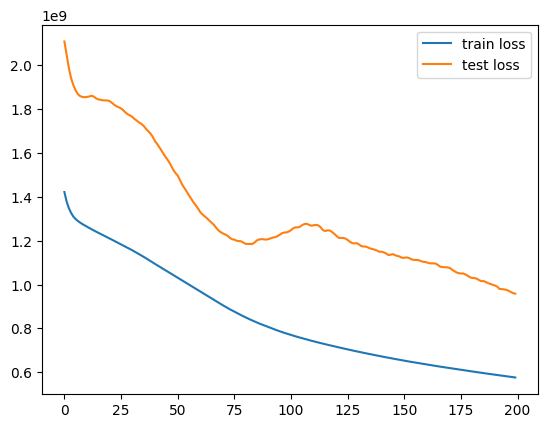

In [114]:
plt.plot(r.history['loss'], label='train loss')
plt.plot(r.history['val_loss'], label='test loss')
plt.legend();

In [115]:
Ptrain = model.predict(Xtrain_m)
Ptest = model.predict(Xtest_m)

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step


In [116]:
Ptrain.shape, Ptest.shape

((100, 12), (1, 12))

In [117]:
Ptrain = Ptrain[:,0]
Ptest = Ptest[0]

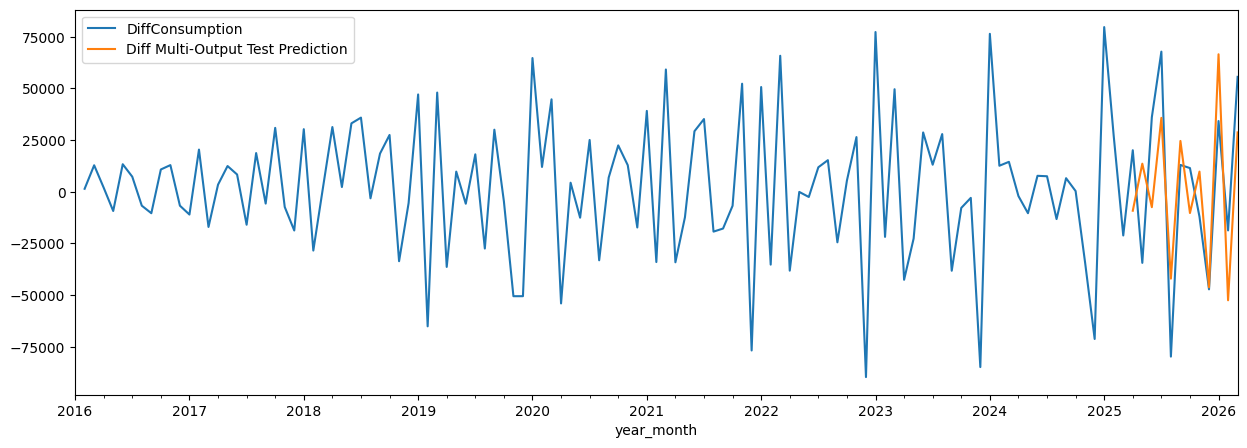

In [118]:
df.loc[test_idx, 'Diff Multi-Output Test Prediction'] = Ptest
cols = ['DiffConsumption', 'Diff Multi-Output Test Prediction']
df[cols].plot(figsize=(15, 5));

In [119]:
# save multi-output forecast to dataframe
df.loc[test_idx, 'multioutput'] = last_train + \
  np.cumsum(Ptest)

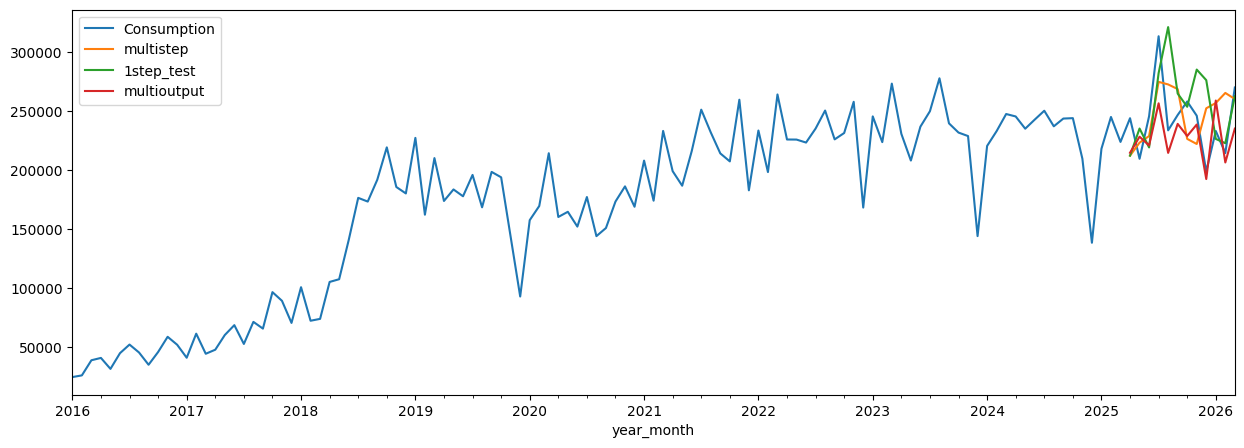

In [120]:
# plot all forecasts
cols = ['Consumption', 'multistep', '1step_test', 'multioutput']
df[cols].plot(figsize=(15, 5));

In [121]:
test_log_pass = df.iloc[-Ntest:]['Consumption']

mae1 = mean_absolute_error(
    test_log_pass, df.loc[test_idx, 'multistep'])
print("multi-step MAE:", mae1)
mape1 = mean_absolute_percentage_error(
    test_log_pass, df.loc[test_idx, 'multistep'])
print("multi-step MAPE:", mape1)
rmse1 = math.sqrt(mean_squared_error(test_log_pass, df.loc[test_idx, 'multistep']))
print("multi-step RMSE:", rmse1)
mae2 = mean_absolute_error(
    test_log_pass, df.loc[test_idx, 'multioutput'])
print("multi-output MAE:", mae2)
mape2 = mean_absolute_percentage_error(
    test_log_pass, df.loc[test_idx, 'multioutput'])
print("multi-output MAPE:", mape2)
rmse2 = math.sqrt(mean_squared_error(test_log_pass, df.loc[test_idx, 'multioutput']))
print("multi-output MAPE:", rmse2)

multi-step MAE: 29629.36153157552
multi-step MAPE: 0.1257761850117377
multi-step RMSE: 32500.99153280414
multi-output MAE: 22352.618774414062
multi-output MAPE: 0.08819574793525342
multi-output MAPE: 26427.290101960432


## **Auto-Arima**



In [122]:
df.head()

,Consumption,DiffConsumption,Diff Train Prediction,Diff Test Prediction,ShiftConsumption,1step_train,1step_test,multistep,Diff Multi-Output Test Prediction,multioutput
year_month,,,,,,,,,,
2016-01-31,24273,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2016-02-29,25715,1442.0,NaN,NaN,24273.0,NaN,NaN,NaN,NaN,NaN
2016-03-31,38543,12828.0,NaN,NaN,25715.0,NaN,NaN,NaN,NaN,NaN
2016-04-30,40524,1981.0,NaN,NaN,38543.0,NaN,NaN,NaN,NaN,NaN
2016-05-31,31222,-9302.0,NaN,NaN,40524.0,NaN,NaN,NaN,NaN,NaN


In [123]:
df.columns

Index(['Consumption', 'DiffConsumption', 'Diff Train Prediction',
       'Diff Test Prediction', 'ShiftConsumption', '1step_train', '1step_test',
       'multistep', 'Diff Multi-Output Test Prediction', 'multioutput'],
      dtype='object')

In [124]:
df=df.drop(['DiffConsumption', 'Diff Train Prediction',
       'Diff Test Prediction', 'ShiftConsumption', '1step_train', '1step_test',
       'multistep', 'Diff Multi-Output Test Prediction', 'multioutput'],axis=1)

In [125]:
!pip install pmdarima

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 689.1/689.1 kB 8.9 MB/s eta 0:00:00


In [126]:
import pmdarima as pm

In [127]:
model = pm.auto_arima(train['Consumption'],
                      trace=True,
                      suppress_warnings=True,
                      seasonal=True, m=12)

Performing stepwise search to minimize aic
 ARIMA(2,1,2)(1,0,1)[12] intercept   : AIC=2555.235, Time=1.36 sec
 ARIMA(0,1,0)(0,0,0)[12] intercept   : AIC=2606.270, Time=0.09 sec
 ARIMA(1,1,0)(1,0,0)[12] intercept   : AIC=2550.973, Time=0.40 sec
 ARIMA(0,1,1)(0,0,1)[12] intercept   : AIC=2555.537, Time=0.32 sec
 ARIMA(0,1,0)(0,0,0)[12]             : AIC=2604.602, Time=0.82 sec
 ARIMA(1,1,0)(0,0,0)[12] intercept   : AIC=2581.281, Time=0.07 sec
 ARIMA(1,1,0)(2,0,0)[12] intercept   : AIC=2552.768, Time=1.44 sec
 ARIMA(1,1,0)(1,0,1)[12] intercept   : AIC=2552.904, Time=1.78 sec
 ARIMA(1,1,0)(0,0,1)[12] intercept   : AIC=2558.436, Time=0.79 sec
 ARIMA(1,1,0)(2,0,1)[12] intercept   : AIC=2554.470, Time=1.56 sec
 ARIMA(0,1,0)(1,0,0)[12] intercept   : AIC=2564.976, Time=0.30 sec
 ARIMA(2,1,0)(1,0,0)[12] intercept   : AIC=2551.368, Time=0.78 sec
 ARIMA(1,1,1)(1,0,0)[12] intercept   : AIC=2552.035, Time=1.56 sec
 ARIMA(0,1,1)(1,0,0)[12] intercept   : AIC=2550.707, Time=0.75 sec
 ARIMA(0,1,1)(0,0,0

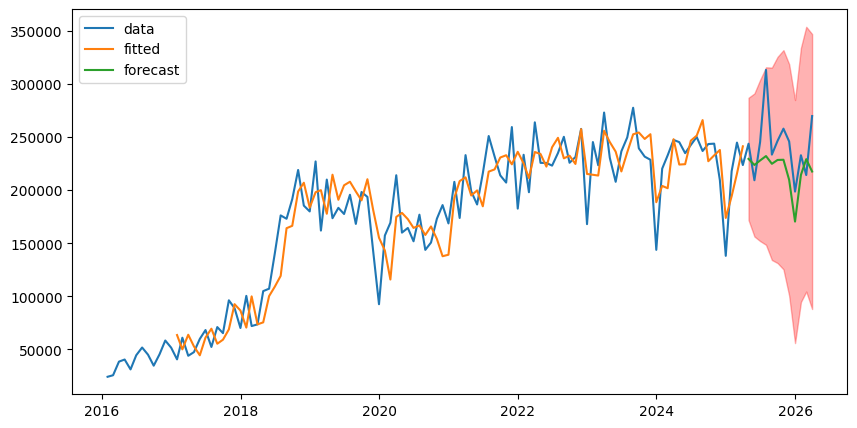

In [128]:
# Since the model is seasonal, we won't plot or predict the first 12
# values (since pmdarima will set them to 0)
train_pred = model.predict_in_sample(start=12, end=-1)
test_pred, confint = model.predict(n_periods=Ntest, return_conf_int=True)

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(df.index, df['Consumption'], label='data')
ax.plot(train.index[12:], train_pred, label='fitted')
ax.plot(test.index, test_pred, label='forecast')
ax.fill_between(test.index, \
                confint[:,0], confint[:,1], \
                color='red', alpha=0.3)
ax.legend();

In [129]:
mean_absolute_error(test['Consumption'], test_pred)

27793.01606633789

In [130]:
mean_absolute_percentage_error(test['Consumption'], test_pred)

0.10948962661224532

In [131]:
math.sqrt(mean_squared_error(test['Consumption'], test_pred))

34116.86451657382

In [132]:
# Best non-seasonal model
model = pm.auto_arima(train['Consumption'],
                      trace=True,
                      max_p=12, max_q=2, max_order=14,
                      suppress_warnings=True,
                      stepwise=False,
                      seasonal=False)

 ARIMA(0,1,0)(0,0,0)[0] intercept   : AIC=2606.270, Time=0.02 sec
 ARIMA(0,1,1)(0,0,0)[0] intercept   : AIC=2575.237, Time=0.04 sec
 ARIMA(0,1,2)(0,0,0)[0] intercept   : AIC=2578.557, Time=0.05 sec
 ARIMA(1,1,0)(0,0,0)[0] intercept   : AIC=2581.281, Time=0.04 sec
 ARIMA(1,1,1)(0,0,0)[0] intercept   : AIC=2576.578, Time=0.05 sec
 ARIMA(1,1,2)(0,0,0)[0] intercept   : AIC=2571.666, Time=0.19 sec
 ARIMA(2,1,0)(0,0,0)[0] intercept   : AIC=2580.723, Time=0.04 sec
 ARIMA(2,1,1)(0,0,0)[0] intercept   : AIC=2578.942, Time=0.10 sec
 ARIMA(2,1,2)(0,0,0)[0] intercept   : AIC=2572.945, Time=0.21 sec
 ARIMA(3,1,0)(0,0,0)[0] intercept   : AIC=2576.360, Time=0.06 sec
 ARIMA(3,1,1)(0,0,0)[0] intercept   : AIC=2577.205, Time=0.08 sec
 ARIMA(3,1,2)(0,0,0)[0] intercept   : AIC=2579.537, Time=0.29 sec
 ARIMA(4,1,0)(0,0,0)[0] intercept   : AIC=2577.125, Time=0.14 sec
 ARIMA(4,1,1)(0,0,0)[0] intercept   : AIC=2579.066, Time=0.46 sec
 ARIMA(4,1,2)(0,0,0)[0] intercept   : AIC=2576.212, Time=1.03 sec
 ARIMA(5,1

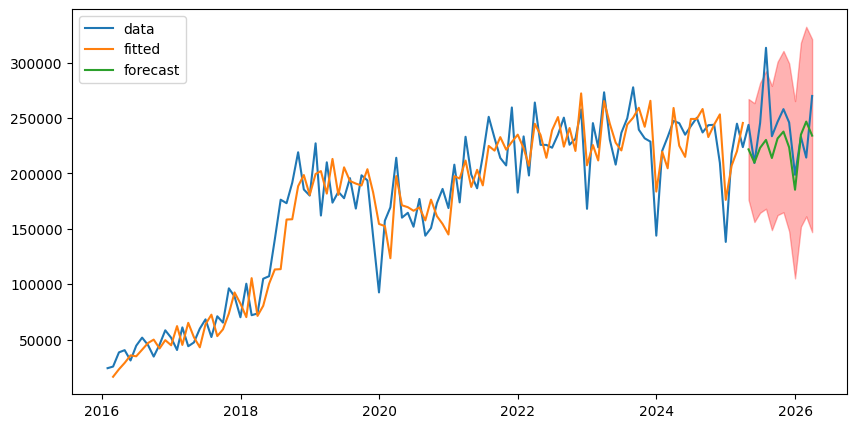

In [133]:
train_pred = model.predict_in_sample(start=1, end=-1)
test_pred, confint = model.predict(n_periods=Ntest, return_conf_int=True)

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(df.index, df['Consumption'], label='data')
ax.plot(train.index[1:], train_pred, label='fitted')
ax.plot(test.index, test_pred, label='forecast')
ax.fill_between(test.index, \
                confint[:,0], confint[:,1], \
                color='red', alpha=0.3)
ax.legend();

In [134]:
mean_absolute_error(test['Consumption'], test_pred)

24090.491404110013

In [135]:
mean_absolute_percentage_error(test['Consumption'], test_pred)

0.09370082729210212

In [136]:
math.sqrt(mean_squared_error(test['Consumption'], test_pred))

31548.91275618338